In [ ]:
!pip install koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

# 데이터 전처리(데이터 분리, 스케일링, 인코딩, 파이프라인(데이터 누수 방지))관련
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 모델 학습 및 성능평가 관련
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score # (y_true, y_pred, sample_weight(Default=None))


In [ ]:
# 데이터 로드 & 확인
# train 데이터
calories_data = pd.read_csv("/content/final_train_adj_v10.csv")
calories_data.columns = [c.strip() for c in calories_data.columns]    # 컬럼명 앞뒤 공백 제거

print(calories_data.shape)    # (7500, 12)
display(calories_data.info())

# 중복 데이터 확인
dup_rows = calories_data[calories_data.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")
print("중복 개수:", calories_data.duplicated().sum())

# 중복 샘플 드랍
calories_data = calories_data.drop_duplicates(keep="first")
print("남아있는 중복 개수:", calories_data.duplicated().sum())

(7500, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   body_temp                  7500 non-null   float64
 2   bpm                        7500 non-null   float64
 3   height_feet                7500 non-null   float64
 4   height_inche               7500 non-null   float64
 5   weight_lb                  7500 non-null   float64
 6   age                        7500 non-null   int64  
 7   bmi                        7500 non-null   float64
 8   bsa_intensity_time         7500 non-null   float64
 9   exercise_stress_index_raw  7500 non-null   float64
 10  weight_status              7500 non-null   object 
 11  gender                     7500 non-null   object 
 12  age_section                7500 non-null   object 
 13  bpm_section                7500 non-n

None

중복 확인:
      ex_dura  body_temp   bpm  height_feet  height_inche  weight_lb  age  \
4251      9.0      103.1  90.0          5.0           5.0      130.1   28   
4662      9.0      103.1  90.0          5.0           5.0      130.1   28   

        bmi  bsa_intensity_time  exercise_stress_index_raw  weight_status  \
4251  21.65             6.94029                   49.29503  Normal Weight   
4662  21.65             6.94029                   49.29503  Normal Weight   

     gender age_section bpm_section ex_section  pre_cal_rounded  \
4251      F         20대         mid     ex_mid             40.0   
4662      F         20대         mid     ex_mid             40.0   

      calories_burned  
4251             40.0  
4662             40.0  
중복 개수: 1
남아있는 중복 개수: 0


In [ ]:
# X, y 분리
X = calories_data[['pre_cal_rounded']].copy()
y = calories_data['calories_burned'].copy()

# train, validation 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 분리된 형태 확인
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((5999, 1), (1500, 1), (5999,), (1500,))

In [ ]:
# -------------------------
# 1) 모델 정의
# -------------------------
lr = LinearRegression()

# -------------------------
# 2) 모델 학습
# -------------------------
print("모델 학습중...")
lr.fit(X_train, y_train)
print("모델 학습 완료!🎉")

모델 학습중...
모델 학습 완료!🎉


In [ ]:
# 베이스 모델 예측 및 평가
y_preds = lr.predict(X_valid)

mse = mean_squared_error(y_valid, y_preds)
rmse = root_mean_squared_error(y_valid, y_preds)

print(f"y의 평균: {y_train.mean():.2f}")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

y의 평균: 89.17
MSE (Mean Squared Error): 0.00
RMSE (Root Mean Squared Error): 0.06


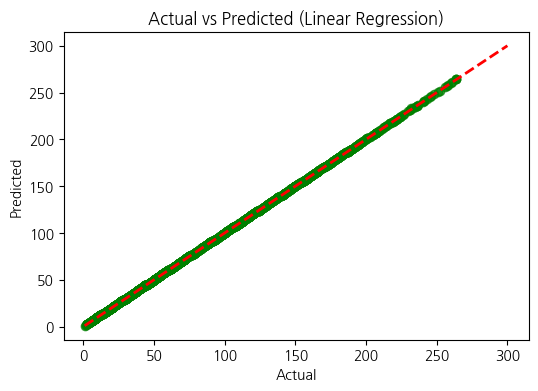

In [ ]:
# (시각화) 실제값 vs 예측값 비교
plt.figure(figsize=(6, 4))
plt.scatter(y_valid, y_preds, alpha=0.7, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 대각선 (완벽한 예측선)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [ ]:
# 결과 해석: 회귀계수
print(f"절편 (Intercept): {np.round(lr.intercept_, 2)}")


절편 (Intercept): -0.0


In [ ]:
# 테스트 데이터 로드
calories_test_data = pd.read_csv("/content/final_test_v10.csv")
calories_test_data.columns = [c.strip() for c in calories_test_data.columns]    # 컬럼명 앞/뒤 공백 제거
X_test = calories_test_data

# 데이터 확인
print(f"데이터 크기: {X_test.shape}")
display(X_test.info())
dup_rows = X_test[X_test.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")

데이터 크기: (7500, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   body_temp                  7500 non-null   float64
 2   bpm                        7500 non-null   float64
 3   height_feet                7500 non-null   float64
 4   height_inche               7500 non-null   float64
 5   weight_lb                  7500 non-null   float64
 6   age                        7500 non-null   int64  
 7   bmi                        7500 non-null   float64
 8   bsa_intensity_time         7500 non-null   float64
 9   exercise_stress_index_raw  7500 non-null   float64
 10  weight_status              7500 non-null   object 
 11  gender                     7500 non-null   object 
 12  age_section                7500 non-null   object 
 13  bpm_section                75

None

중복 확인:
Empty DataFrame
Columns: [ex_dura, body_temp, bpm, height_feet, height_inche, weight_lb, age, bmi, bsa_intensity_time, exercise_stress_index_raw, weight_status, gender, age_section, bpm_section, ex_section, pre_cal_rounded]
Index: []


In [ ]:
# 테스트 데이터 예측
X = X_test[['pre_cal_rounded']].copy()
final_pred = lr.predict(X)

In [ ]:
# 제출 파일 제작
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = final_pred
submission.to_csv('./submit.csv', index = False, encoding="utf-8")

# 사용한 변수 관련 부여 설명 코드

In [ ]:

from sklearn.linear_model import LinearRegression

# 1. 성별 분리 (성별에 따라 대사량 공식이 다름을 가설로 설정)
df_m = calories_data[calories_data['gender'] == 'M'].copy()
df_f = calories_data[calories_data['gender'] == 'F'].copy()

def reverse_cal_function(gender_df, gender_name):

    # [Step 1] 가설 수립 및 교호작용(Interaction) 변수 생성
    # 일반적인 칼로리 공식: (a*Age + b*Weight_kg + c*BPM + d) * Duration / 4.184  (단위 변환: 1 kcal = 4.184 kJ)
    # 즉, 식이 (A*(Duration*Age) + B*(Duration*Weight) + C*(Duration*BPM) + D*Duration) / 4.184 = y 일 것으로 예상됨
    # 이 구조에 맞춰 피처를 세팅
    X = pd.DataFrame() # 빈 데이터 프레임 생성
    # 변수들 정의
    X['Dur_Age'] = gender_df['ex_dura'] * gender_df['age']
    X['Dur_Weight'] = gender_df['ex_dura'] * gender_df['weight_kg']
    X['Dur_BPM'] = gender_df['ex_dura'] * gender_df['bpm']
    X['Duration_Only'] = gender_df['ex_dura'] # 식의 상수항(d) 역할을 할 변수.
    # 즉, 위의 변수들을 선형모델에 넣고 회귀계수(A, B, C)를 구하면 식이 나오는 셈

    y = gender_df['calories_burned']

    # [Step 2] 선형 회귀 적합 (수학 공식을 찾기 위해 절편 fit_intercept=False 설정)
    lr = LinearRegression(fit_intercept=False)
    lr.fit(X, y)

    # [Step 3] 칼로리 변환 상수(4.184)를 곱해서 원래의 생리학 계수 복원
    # 선형 회귀가 찾은 계수에 4.184를 곱하면 원본 상수들이 튀어나와야 함
    coef_restored = lr.coef_ * 4.184

    print("\n선형 회귀를 통해 복원된 기본 계수 (4.184 곱셈 후)")
    print(f" - Age 계수   : {coef_restored[0]:.6f}")
    print(f" - Weight : {coef_restored[1]:.6f}")
    print(f" - BPM 계수   : {coef_restored[2]:.6f}")
    print(f" - 상수항(d)  : {coef_restored[3]:.6f}")
    print(f" - 수식: ( {coef_restored[0]:.6f} * age + {coef_restored[1]:.6f} * weight_kg + {coef_restored[2]:.6f} * bpm + {coef_restored[3]:.6f} ) * ex_dura / 4.184")


# 남성 수식
print("남성 수식")
reverse_cal_function(df_m, '남성')

# 여성 수식
print("\n여성 수식")
reverse_cal_function(df_f, '여성')

In [ ]:
# 연령대 구분 함수
def age_section(age):
    if age < 30:
        return "20대"
    elif age < 40:
        return "30대"
    elif age < 50:
        return "40대"
    elif age < 60:
        return "50대"
    elif age < 70:
        return "60대"
    else:
        return "70대"

# weight_kg 변환 함수
def weight_kg(weight_lb):
    weight_kg = weight_lb * 0.45359237
    return weight_kg

# 체온 변환 함수
def body_temp(body_temp):
    body_temp = (body_temp - 32)/1.8
    return round(body_temp, 1)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    원본 df를 받아 파생변수를 추가한 df를 반환
    """
    out = df.copy()

    # 1) 연령대
    if "age" in out.columns:
        out["age_section"] = out["age"].apply(age_section)

    # 2) 키 단위 변환
    out["height_cm"] = ((out["height_feet"] * 12) + out["height_inche"]) * 2.54

    # 3) 몸무게 변환
    if "weight_lb" in out.columns:
        out["weight_kg"] = out["weight_lb"].apply(weight_kg)

    # 4) 체온 변환
    if "body_temp" in out.columns:
        out["body_temp_c"] = out["body_temp"].apply(body_temp)

# 3. 파생 변수 생성
    # 1) bmi 컬럼 추가 (WHO기준)
    out["bmi"] = round(out["weight_kg"]/((out["height_cm"]/100)**2), 2)
    def bmi_category(bmi):
      if bmi < 18.5:
        return "저체중"
      elif bmi < 25:
        return "정상"
      elif bmi < 30:
        return "과체중"
      else:
        return "비만"

    out["bmi_category"] = out["bmi"].apply(bmi_category)


    # 2) bsa 컬럼 추가 (체표면적)
    out["bsa"] = np.sqrt((out["height_cm"] * out["weight_kg"])/3600)

    # 3) 최대 심박수 계산
    if "age" in out.columns:
        out["max_hr"] = 220 - out["age"]

    # 4) HR_ratio (강도 지표)
    if "bpm" in out.columns:
        out["hr_ratio"] = out["bpm"] / out["max_hr"]

    # 5) Activity proxy : 체중:Weight× 시간:Duration × 강도:Intensity
         # 활동에너지의 구조를 반영한 파생변수 (MET 없음, 산소 소비량 없으므로)
    if all(col in out.columns for col in ["weight_kg", "ex_dura", "hr_ratio"]):
        out["activity_proxy"] = (
            out["weight_kg"] *
            out["ex_dura"] *
            out["hr_ratio"]
        )


    # 6) 체표면적 기반 운동부하 지표: BSA × 강도 × 시간 구조 (신체크기 * 운동 지속시간 * 운동 강도 )
    if all(col in out.columns for col in ["bsa", "ex_dura", "hr_ratio"]):
        out["bsa_intensity_time"] = (
            out["bsa"] *
            out["ex_dura"] *
            out["hr_ratio"]
        )


    # 7) 개인 차이를 고려한 정규화 접근
    # 7-1) 체중 대비 심박수
    if all(col in out.columns for col in ["bpm", "weight_kg"]):
        out["bpm_per_kg"] = out["bpm"] / (out["weight_kg"] + 1e-6)

    # 7-2) 체중 대비 운동 강도
    out['hr_load_per_kg'] = (out['bpm'] * out['ex_dura']) / out['weight_kg']
    out['hr_load_per_bsa'] = (out['bpm'] * out['ex_dura']) / out['bsa']

    # 새로운 변수
    g = out["gender"].astype(str).str.upper().str.strip()   # 또는 "Gender"일 수 있음

    male = (-55.0969 + 0.6309*out["hr_ratio"] + 0.1988*out["weight_kg"] + 0.2017*out["age"]) * out["ex_dura"] / 4.184
    female = (-20.4022 + 0.4472*out["hr_ratio"] - 0.1263*out["weight_kg"] + 0.0740*out["age"]) * out["ex_dura"] / 4.184

    out["hr_wt_age_dura"] = np.where(g.eq("M"), male, female).round()

    out["exercise_stress_index_raw"] = np.sqrt(out["ex_dura"] * (out["bpm"] / 1.5) * (out["body_temp"] - 98.6))

    out['ex_stress_index_new'] = out['ex_dura'] * (out['bpm'] + out['bsa'] + out['age']) * (out["body_temp"] - 98.6)

    def bpm_section(bpm):
      if bpm < 80.0:
        return "low"
      elif bpm < 100:
        return "mid"
      else:
        return "high"

    out["bpm_section"] = out["bpm"].apply(bpm_section)

    def ex_section(ex_dura):
      if ex_dura < 7:
        return "ex_low"
      elif ex_dura < 15:
        return "ex_mid"
      else:
        return "ex_high"

    out["ex_section"] = out["ex_dura"].apply(ex_section)

    # pre_cal 변수 생성(논문 참고 후 수식 일부 수정)
    male_cal = ((out['age'] * 0.2017) + (out["weight_kg"] * 0.09036) + (out['bpm'] * 0.6309) - 55.0969) * out['ex_dura'] / 4.184
    female_cal = ((out['age'] * 0.074) - (out["weight_kg"] * 0.05741) + (out['bpm'] * 0.4472) - 20.4022) * out['ex_dura'] / 4.184

    # 값 합치기
    is_male = out['gender'].str.upper().str.strip() == 'M'
    out['pre_cal'] = np.where(is_male, male_cal, female_cal)
    # 반올림
    out['pre_cal_rounded'] = np.floor(out['pre_cal'] + 0.5)

    return out

calories_data = add_features(calories_data)

display(calories_data.head(10))
calories_data.shape